## UMAP

In [2]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

# wczytanie datasetu
data = pd.read_csv('dataset_A_hands.csv', header = 0)
data.head()

,FC5,FC3,FC1,FCz,FC2,FC4,FC6,C5,C3,C1,...,PO7,PO3,POz,PO4,PO8,O1,Oz,O2,Iz,Label
0,-11.368526,-11.424228,-11.585911,-11.587444,-11.516528,-11.458961,-11.326939,-11.408007,-11.629599,-11.656776,...,-11.226600,-11.357553,-11.381296,-11.238655,-11.062158,-11.126559,-11.223495,-11.151625,-10.948594,Task3
1,-11.284149,-11.422955,-11.369446,-11.320009,-11.390571,-11.411450,-11.411991,-11.402370,-11.569449,-11.696185,...,-10.981480,-11.025114,-11.026598,-11.063468,-11.030770,-10.868531,-10.866038,-10.920515,-10.739326,Task1
2,-11.431263,-11.430120,-11.482541,-11.534096,-11.495824,-11.367992,-11.330367,-11.383096,-11.557855,-11.698244,...,-10.891545,-11.036507,-11.060690,-10.976081,-10.770071,-10.759802,-10.705004,-10.659787,-10.439506,Task2
3,-11.446603,-11.464615,-11.413162,-11.382691,-11.351718,-11.438916,-11.399082,-11.362765,-11.628451,-11.667057,...,-10.949354,-11.032611,-11.052224,-10.937487,-10.974803,-10.871874,-10.841078,-10.876684,-10.661939,Task2
4,-11.467128,-11.599652,-11.588888,-11.570401,-11.589498,-11.433946,-11.456305,-11.366391,-11.675037,-11.676603,...,-11.082195,-11.126224,-11.142371,-11.117976,-10.992686,-10.988595,-11.030893,-11.036307,-10.890251,Task1


## Współrzędne równoległe dla top 30 najbardziej zmiennych cech EEG

Klasy nie są łatwo separowalne liniowo w oryginalnej przestrzeni, problem jest silnie nieliniowy.

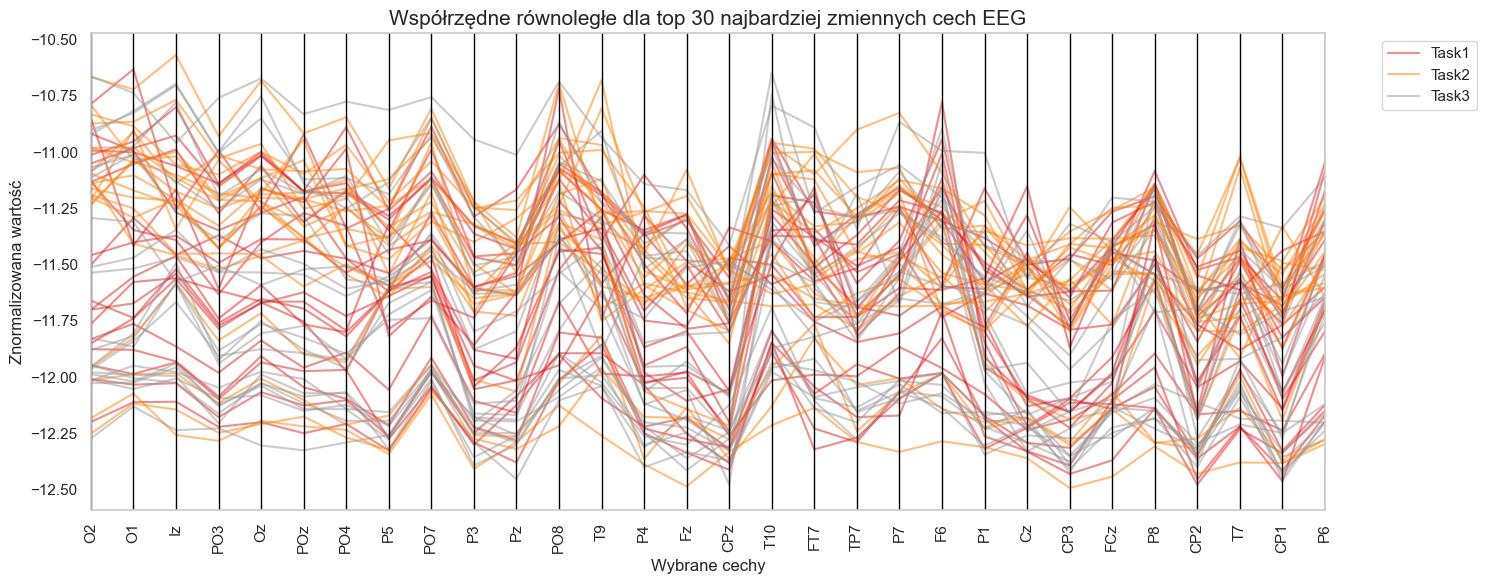

In [3]:
from pandas.plotting import parallel_coordinates

X = data.drop(columns=['Label'])
y = data['Label']

top_features = X.var().nlargest(30).index # top 30 cech o największej wariancji

df_subset = data.groupby('Label').sample(n=20, random_state=42) # wybór 20 próbek z każdej klasy
df_parallel = df_subset[list(top_features) + ['Label']]

plt.figure(figsize=(15, 6))
parallel_coordinates(df_parallel, 'Label', colormap=plt.get_cmap("Set1"), alpha=0.5)
plt.title('Współrzędne równoległe dla top 30 najbardziej zmiennych cech EEG', fontsize=15)
plt.xlabel('Wybrane cechy')
plt.ylabel('Znormalizowana wartość')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [4]:
def plot_umap(data, embedding, title):
    label_map = {
        "Task1":0, "Task2":1, "Task3":2
    }
    labels_num = data['Label'].map(label_map).fillna(-1).astype(int)

    plt.figure()
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=data['Label'],
        palette="Set1",
        s=80,
        alpha=0.8,
        hue_order=["Task1", "Task2", "Task3"]
    )

    plt.gca().set_aspect('equal', 'datalim')
    plt.title(title, fontsize=18)
    plt.legend(title="Zadanie", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

(415, 2)


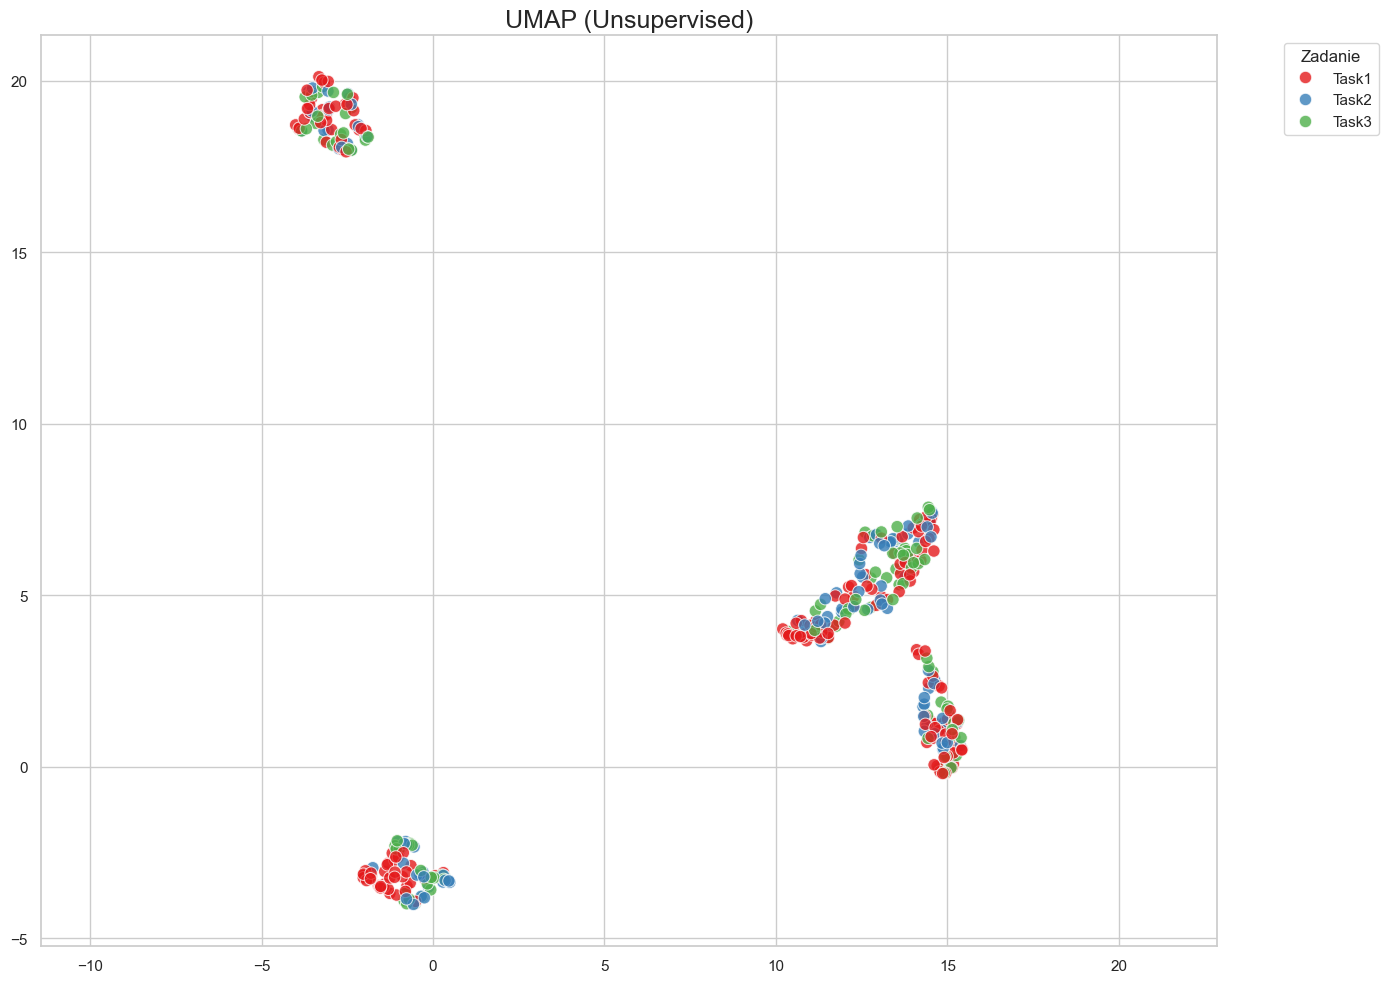

In [5]:
# UMAP NIENADZOROWANY (Unsupervised)
warnings.filterwarnings('ignore')

reducer = umap.UMAP(n_components=2, random_state=42)

embedding = reducer.fit_transform(X)
print(embedding.shape)

plot_umap(data, embedding, title="UMAP (Unsupervised)")

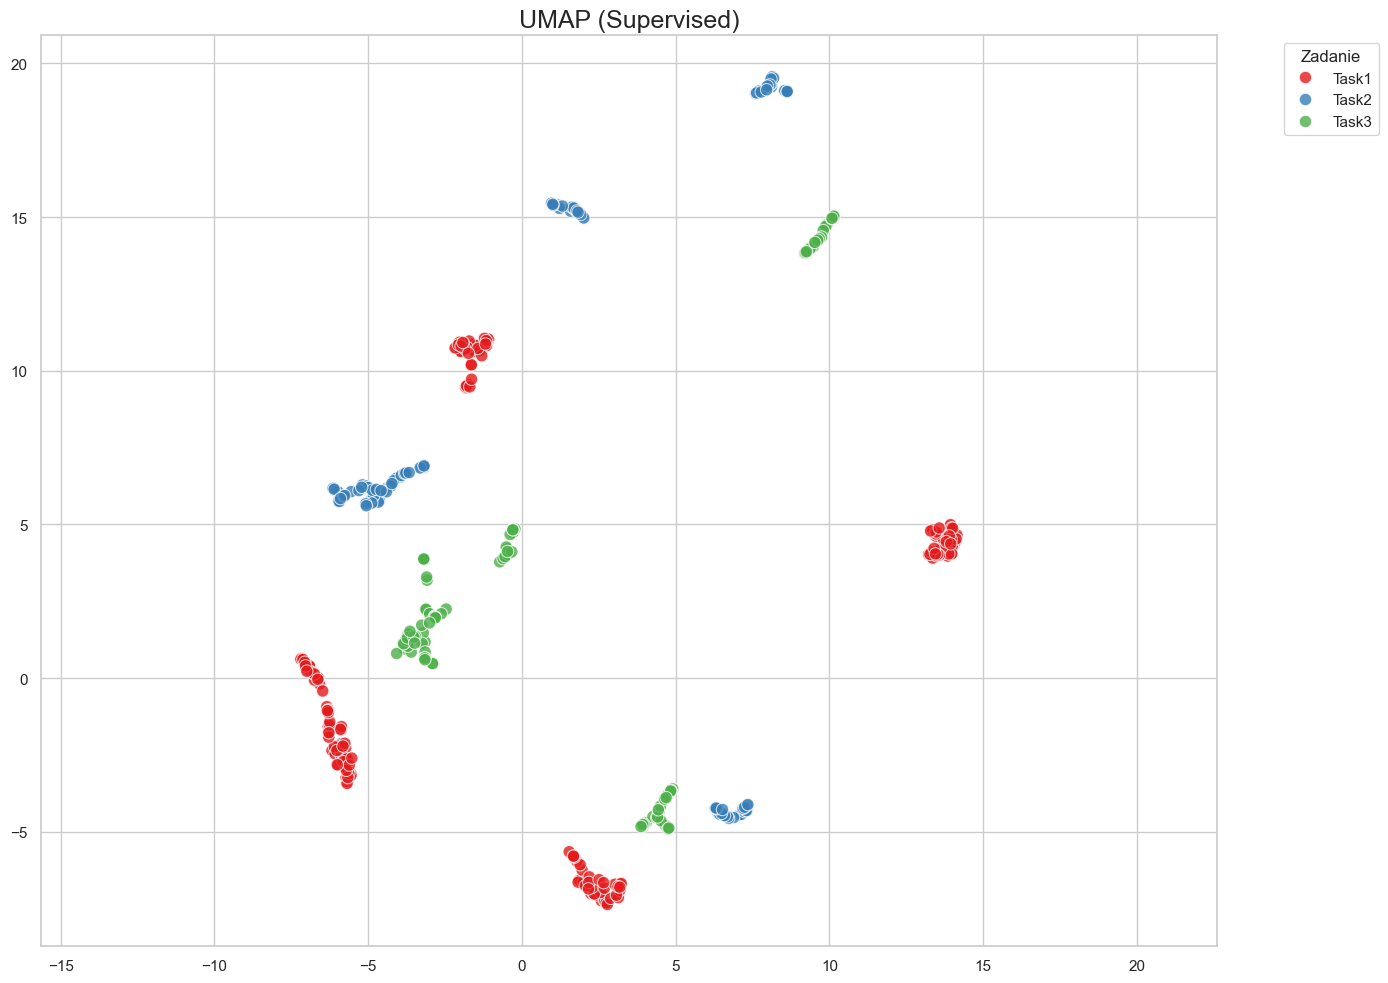

In [6]:
# UMAP NADZOROWANY (Supervised)
warnings.filterwarnings('ignore')

label_map = {"Task1":0, "Task2":1, "Task3":2, "Task4":3, "Task5":4, "Task6":5}
y_num = y.map(label_map).fillna(-1).astype(int)

reducer_supervised = umap.UMAP(n_components=2, random_state=42)

embedding_sup = reducer_supervised.fit_transform(X, y=y_num)
embedding.shape

plot_umap(data, embedding_sup, title="UMAP (Supervised)")

## Test 1: trustworthiness

Miara określająca jaki odsetek sąsiadów z przestrzeni wysokowymiarowej pozostaje sąsiadami po redukcji.

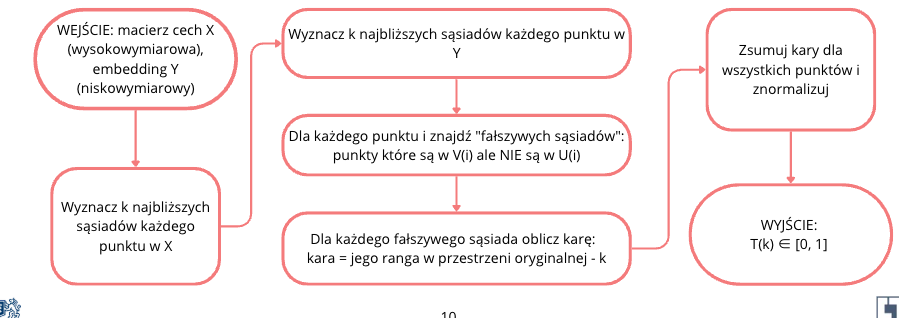

In [7]:
# test 1 UMAP - trustwhorthiness
from sklearn.metrics import pairwise_distances
from sklearn.manifold import trustworthiness

def calculate_trustworthiness(X, Y, k=5):
    """
    X: macierz cech (wysokowymiarowa)
    Y: embedding (niskowymiarowy)
    k: liczba rozpatrywanych najbliższych sąsiadów

    return: trustworthiness
    """

    n = X.shape[0]
    if k <= 0 or k >= n:
        raise ValueError("k must be > 0 and < n_samples")

    dist_X = pairwise_distances(X) # macierz odległości
    ranks_X = np.argsort(np.argsort(dist_X, axis=1), axis=1)

    dist_Y = pairwise_distances(Y)
    ranks_Y = np.argsort(np.argsort(dist_Y, axis=1), axis=1)

    suma_kar = 0

    for i in range(n):
        U_i = np.where((ranks_X[i] >= 1) & (ranks_X[i] <= k))[0] # U(i) - przestrzeń oryginalna
        V_i = np.where((ranks_Y[i] >= 1) & (ranks_Y[i] <= k))[0] # V(i) - przestrzeń po umap

        falszywi_sasiedzi = [j for j in V_i if j not in U_i]

        for j in falszywi_sasiedzi:
            kara =  ranks_X[i, j] - k
            suma_kar += kara

    normalizacja = 2.0 / (n * k * (2 * n - 3 * k - 1))
    T_k = (1.0 - normalizacja * suma_kar)

    return T_k

trustworthiness_unsupervised = calculate_trustworthiness(X, embedding)
trustworthiness_supervised = calculate_trustworthiness(X, embedding_sup)

print(f"Trustworthiness unsupervised (k=5): {trustworthiness_unsupervised:.4f}")
print(f"Trustworthiness supervised (k=5): {trustworthiness_supervised:.4f}")

# sprawdzenie wartości dla gotowej funkcji z biblioteki sklearn
trustworthiness_unsupervised_sklearn = trustworthiness(X, embedding, n_neighbors=5)
trustworthiness_supervised_sklearn = trustworthiness(X, embedding_sup, n_neighbors=5)

print(f"Trustworthiness unsupervised (k=5): {trustworthiness_unsupervised_sklearn:.4f}")
print(f"Trustworthiness supervised (k=5): {trustworthiness_supervised_sklearn:.4f}")

Trustworthiness unsupervised (k=5): 0.9775
Trustworthiness supervised (k=5): 0.9636
Trustworthiness unsupervised (k=5): 0.9775
Trustworthiness supervised (k=5): 0.9636


## Test 2: zachowanie sąsiedztwa

Jaki procent k najbliższych sąsiadów danego punktu jest wspólny przed i po redukcji wymiarów?

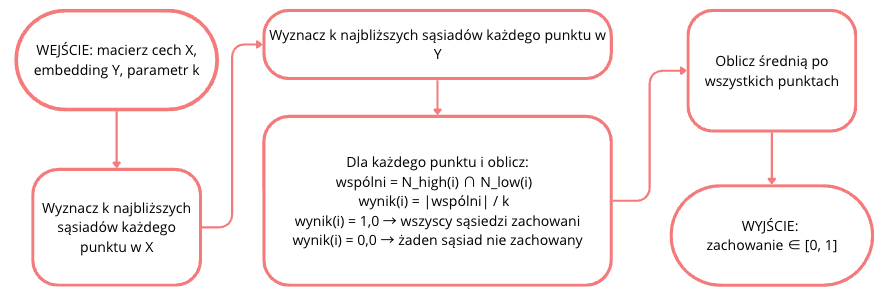

In [8]:
# test 2 UMAP - zachowanie sąsiedztwa
import numpy as np
from sklearn.neighbors import NearestNeighbors

def calculate_neighborhood_preservation(X, Y, k=5):
    """
    X: macierz cech przed redukcją
    Y: embedding po redukcji
    k: liczba rozpatrywanych najbliższych sąsiadów
    """
    n = X.shape[0]

    nn_X = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X)
    _, indices_X = nn_X.kneighbors(X)

    nn_Y = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(Y)
    _, indices_Y = nn_Y.kneighbors(Y)

    suma_wynikow = 0.0

    for i in range(n):
        N_high = set(indices_X[i, 1:])
        N_low  = set(indices_Y[i, 1:])

        wspolni = N_high.intersection(N_low)

        wynik_i = len(wspolni) / k
        suma_wynikow += wynik_i

    srednie_zachowanie = suma_wynikow / n

    return srednie_zachowanie

neighborhood_preservation_unsupervised = calculate_neighborhood_preservation(X, embedding)
neighborhood_preservation_supervised = calculate_neighborhood_preservation(X, embedding_sup)

print(f"Neighborhood Preservation unsupervised (k=5): {neighborhood_preservation_unsupervised:.4f}")
print(f"Neighborhood Preservation supervised (k=5): {neighborhood_preservation_supervised:.4f}")

Neighborhood Preservation unsupervised (k=5): 0.4612
Neighborhood Preservation supervised (k=5): 0.2781


Obliczam: A_hands...
Obliczam: B_feet_fists...
Obliczam: C_combined...
Obliczam: eeg_features...


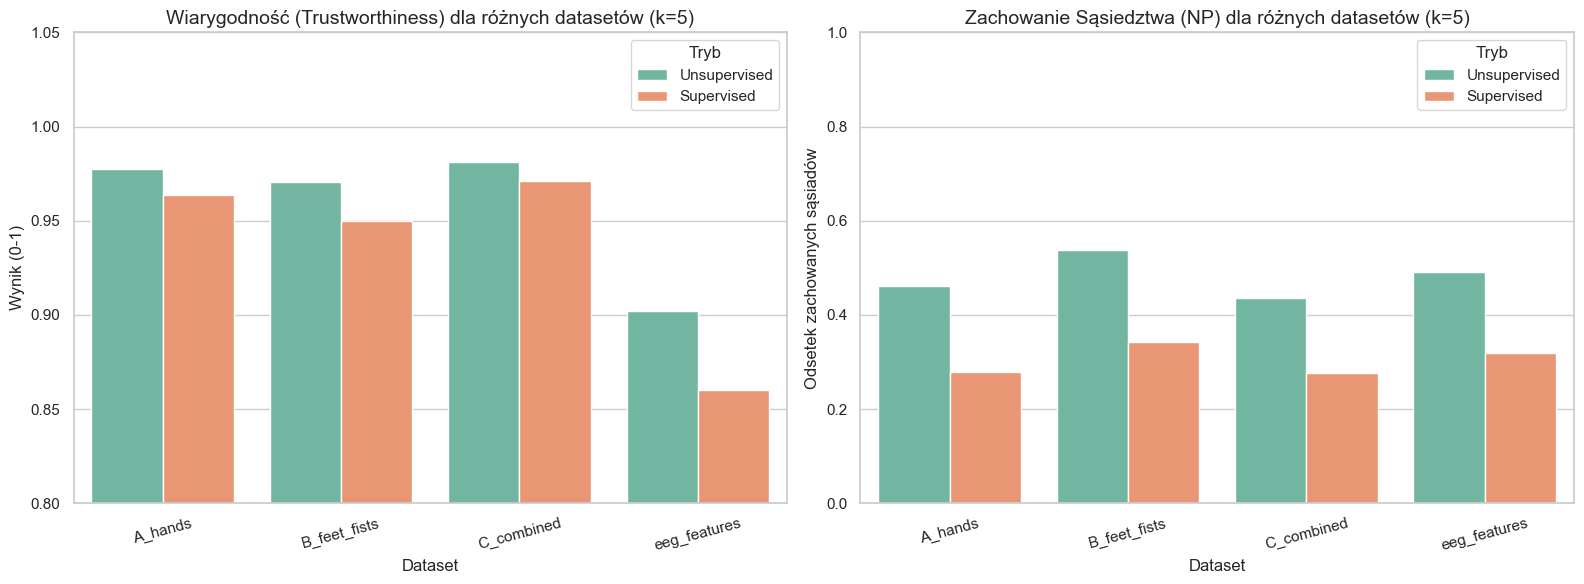

In [9]:
import os
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

sns.set(style='whitegrid', context='notebook')

datasets = [
    'dataset_A_hands.csv',
    'dataset_B_feet_fists.csv',
    'dataset_C_combined.csv',
    'dataset_eeg_features.csv'
]

k = 5
wyniki = []

for plik in datasets:
    if not os.path.exists(plik):
        print(f"[UWAGA] Brak pliku: {plik}")
        continue

    nazwa_ds = plik.replace('dataset_', '').replace('.csv', '') # skrócenie nazwy
    print(f"Obliczam: {nazwa_ds}...")

    df = pd.read_csv(plik, header=0)
    X = df.drop(columns=['Label']).values
    y = df['Label']

    y_num = LabelEncoder().fit_transform(y)

    # UMAP
    emb_unsup = umap.UMAP(n_components=2, random_state=42).fit_transform(X) #unsupervised
    emb_sup = umap.UMAP(n_components=2, random_state=42).fit_transform(X, y=y_num) #supervised

    # Trustworthiness
    t_unsup = trustworthiness(X, emb_unsup, n_neighbors=k)
    t_sup = trustworthiness(X, emb_sup, n_neighbors=k)

    # Neighborhood Preservation
    np_unsup = calculate_neighborhood_preservation(X, emb_unsup, k=k)
    np_sup = calculate_neighborhood_preservation(X, emb_sup, k=k)

    wyniki.append({'Dataset': nazwa_ds, 'Tryb': 'Unsupervised', 'Trustworthiness': t_unsup, 'NP': np_unsup})
    wyniki.append({'Dataset': nazwa_ds, 'Tryb': 'Supervised', 'Trustworthiness': t_sup, 'NP': np_sup})

# wizualizacja
if wyniki:
    df_wyniki = pd.DataFrame(wyniki)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # wykres 1: Trustworthiness
    sns.barplot(data=df_wyniki, x='Dataset', y='Trustworthiness', hue='Tryb', ax=axes[0], palette="Set2")
    axes[0].set_title(f"Wiarygodność (Trustworthiness) dla różnych datasetów (k={k})", fontsize=14)
    axes[0].set_ylabel("Wynik (0-1)")
    axes[0].set_xlabel("Dataset")
    axes[0].set_ylim(0.8, 1.05) # Zawężenie skali dla lepszej czytelności
    axes[0].tick_params(axis='x', rotation=15)

    # wykres 2: Neighborhood Preservation
    sns.barplot(data=df_wyniki, x='Dataset', y='NP', hue='Tryb', ax=axes[1], palette="Set2")
    axes[1].set_title(f"Zachowanie Sąsiedztwa (NP) dla różnych datasetów (k={k})", fontsize=14)
    axes[1].set_ylabel("Odsetek zachowanych sąsiadów")
    axes[1].set_xlabel("Dataset")
    axes[1].set_ylim(0, 1.0)
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()
else:
    print("Błąd generowania wykresów")

## Test 3: sperowalność klas

Czy cztery klasy zbioru PhysioNet tworzą w embeddingu rozróżnialne skupienia?

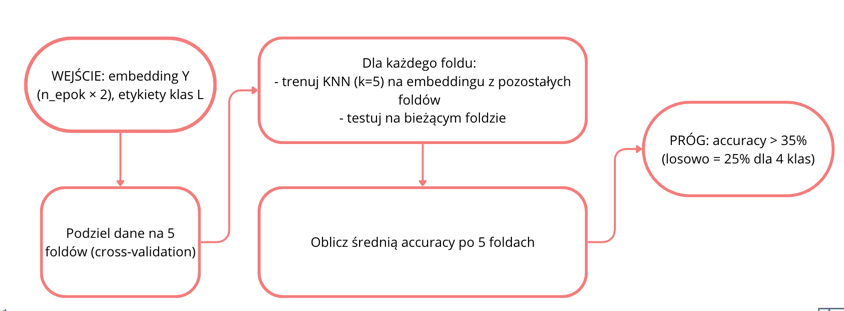

In [10]:
# test 3 UMAP - separowalność klas
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

def calculate_separability(Y, L, k=5, n_splits=5):
    """
    Y: embedding (n_epok x 2)
    L: etykiety klas L
    k: liczba rozpatrywanych najbliższych sąsiadów
    n_splits: liczba foldów cross-validation

    return: średnie accuracy
    """

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=k)

    suma_accuracy = 0.0

    for train_index, test_index in skf.split(Y, L):
        Y_train, Y_test = Y[train_index], Y[test_index]

        if isinstance(L, pd.Series):
            L_train, L_test = L.iloc[train_index], L.iloc[test_index]
        else:
            L_train, L_test = L[train_index], L[test_index]

        knn.fit(Y_train, L_train)

        predictions = knn.predict(Y_test)
        fold_accuracy = accuracy_score(L_test, predictions)

        suma_accuracy += fold_accuracy

    srednie_accuracy = suma_accuracy / n_splits
    return srednie_accuracy

separability_unsupervised = calculate_separability(embedding, data['Label'])
separability_supervised = calculate_separability(embedding_sup, data['Label'])

print(f"Accuracy unsupervised (KNN k=5, 5-fold CV): {separability_unsupervised:.4f}")
print(f"Accuracy supervised (KNN k=5, 5-fold CV): {separability_supervised:.4f}")

# PRÓG: accuracy > 40% (losowo = 33.3% dla 3 klas)
THRESHOLD = 0.40
print(f"Unsupervised > 40%? {'Tak' if separability_unsupervised > THRESHOLD else 'Nie'}")
print(f"Supervised < 40%? {'Tak' if separability_supervised > THRESHOLD else 'Nie'}")

Accuracy unsupervised (KNN k=5, 5-fold CV): 0.4410
Accuracy supervised (KNN k=5, 5-fold CV): 0.9952
Unsupervised > 40%? Tak
Supervised < 40%? Tak


## Test 4: wpływ hiperparametrów

Czy algorytm zachowuje się zgodnie ze swoimi założeniami teoretycznymi gdy zmieniamy jego hiperparametry?

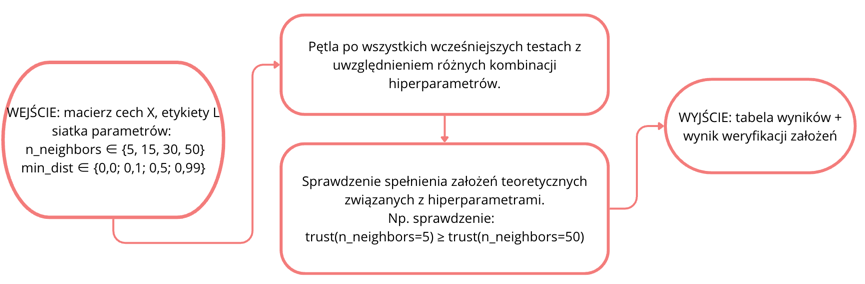

In [11]:
# test 4 UMAP - wpływ hiperparametrów
import umap
import pandas as pd
import warnings

warnings.filterwarnings('ignore') # wyciszenie ostrzeżeń z biblioteki umap

n_neighbors_list = [5, 15, 30, 50]
min_dist_list = [0.0, 0.1, 0.5, 0.99]

wyniki_hiperparametry = []


# Kombinacje hiperparametrów
for n_n in n_neighbors_list:
    for m_d in min_dist_list:

        reducer = umap.UMAP(n_components=2, n_neighbors=n_n, min_dist=m_d, random_state=42) #unsupervised
        Y_emb = reducer.fit_transform(X)

        trust_val = calculate_trustworthiness(X, Y_emb, k=5) #trustworthiness
        np_val = calculate_neighborhood_preservation(X, Y_emb, k=5) #zachowanie sąsiedztwa
        sep_val = calculate_separability(Y_emb, y, k=5, n_splits=5) #separowalność klas

        wyniki_hiperparametry.append({
            'n_neighbors': n_n,
            'min_dist': m_d,
            'trustworthiness': trust_val,
            'neighborhood_preservation': np_val,
            'accuracy_knn': sep_val
        })

df_wyniki = pd.DataFrame(wyniki_hiperparametry)

#print(df_wyniki.head().to_string(index=False))
print(df_wyniki)

# założenia teoretyczne dla parametrów - trustworthiness
min_dist_test = 0.1
trust_5 = df_wyniki[(df_wyniki['n_neighbors'] == 5) & (df_wyniki['min_dist'] == min_dist_test)]['trustworthiness'].values[0]
trust_50 = df_wyniki[(df_wyniki['n_neighbors'] == 50) & (df_wyniki['min_dist'] == min_dist_test)]['trustworthiness'].values[0]

print(f"\nWeryfikacja założeń teoretycznych trustworthiness dla min_dist={min_dist_test}:")
print(f"trustworthiness(n_neighbors=5) = {trust_5:.4f}")
print(f"trustworthiness(n_neighbors=50) = {trust_50:.4f}")

if trust_5 >= trust_50:
    print("Wynik weryfikacji: ZAŁOŻENIE SPEŁNIONE")
else:
    print("Wynik weryfikacji: ZAŁOŻENIE NIE SPEŁNIONE")

# założenia teoretyczne dla parametrów - min_dist
n_neighbors_test = 5
trust_01 = df_wyniki[(df_wyniki['min_dist'] == 0.1) & (df_wyniki['n_neighbors'] == n_neighbors_test)]['trustworthiness'].values[0]

trust_05 = df_wyniki[(df_wyniki['min_dist'] == 0.5) & (df_wyniki['n_neighbors'] == n_neighbors_test)]['trustworthiness'].values[0]
print(f"\nWeryfikacja założeń teoretycznych min_dist dla n neighbors={n_neighbors_test}:")
print(f"trustworthiness(min_dist=0.1) = {trust_01:.4f}")
print(f"trustworthiness(min_dist=0.5) = {trust_05:.4f}")

if trust_01 >= trust_05:
    print("Wynik weryfikacji: ZAŁOŻENIE SPEŁNIONE")
else:
    print("Wynik weryfikacji: ZAŁOŻENIE NIE SPEŁNIONE")

    n_neighbors  min_dist  trustworthiness  neighborhood_preservation  \
0             5      0.00         0.907726                   0.526437   
1             5      0.10         0.908366                   0.514943   
2             5      0.50         0.897425                   0.512644   
3             5      0.99         0.900655                   0.512644   
4            15      0.00         0.905020                   0.489655   
5            15      0.10         0.902168                   0.491954   
6            15      0.50         0.897628                   0.462069   
7            15      0.99         0.890063                   0.439080   
8            30      0.00         0.880285                   0.441379   
9            30      0.10         0.900888                   0.491954   
10           30      0.50         0.892594                   0.418391   
11           30      0.99         0.889597                   0.434483   
12           50      0.00         0.899840         

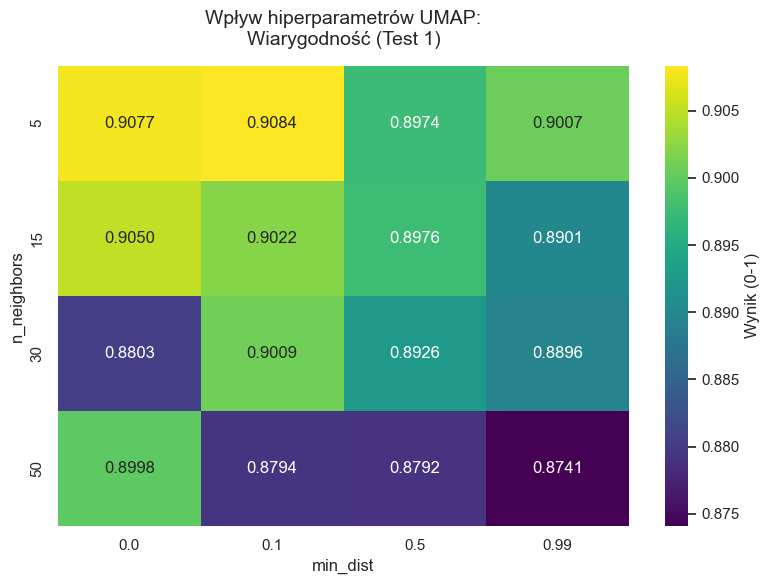

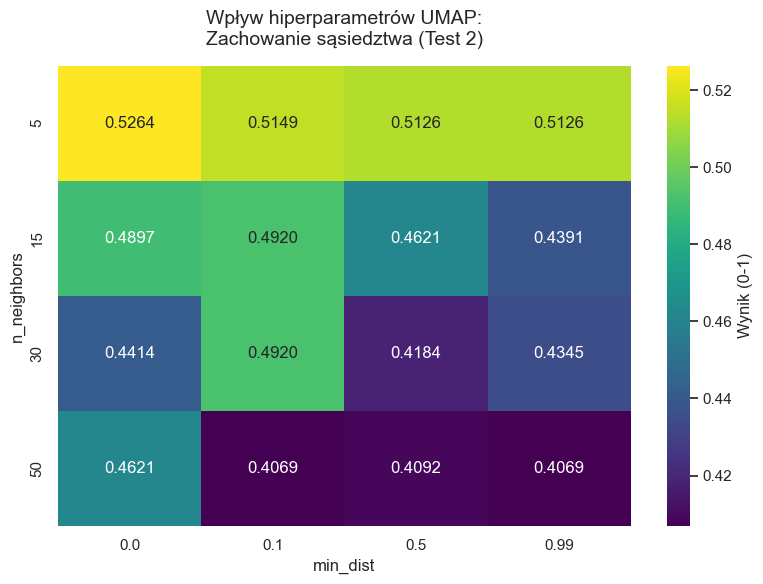

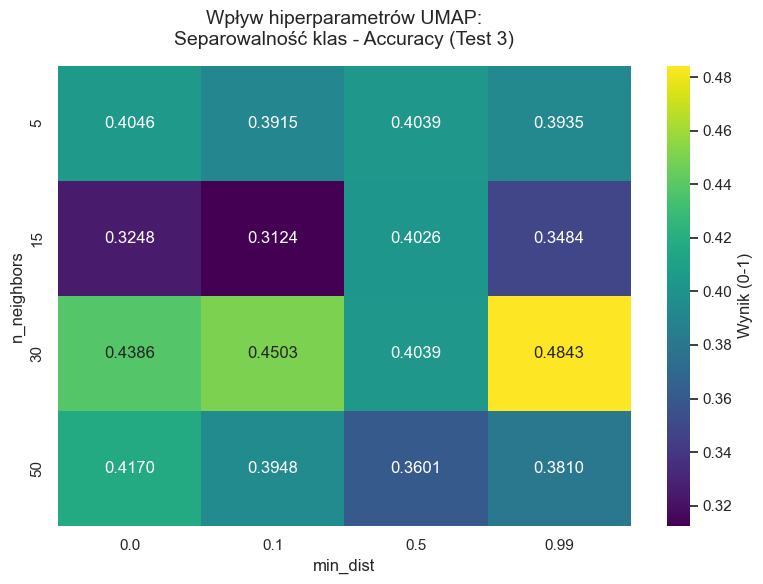

In [14]:
# wizualizacja wyników
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', context='notebook')

metryki = [
    ('trustworthiness', 'Wiarygodność (Test 1)'),
    ('neighborhood_preservation', 'Zachowanie sąsiedztwa (Test 2)'),
    ('accuracy_knn', 'Separowalność klas - Accuracy (Test 3)')
]

for kolumna, tytul in metryki:
    plt.figure(figsize=(8, 6))

    df_pivot = df_wyniki.pivot(index='n_neighbors', columns='min_dist', values=kolumna)
    sns.heatmap(df_pivot, annot=True, fmt=".4f", cmap="viridis",
                cbar_kws={'label': 'Wynik (0-1)'})

    plt.title(f'Wpływ hiperparametrów UMAP:\n{tytul}', fontsize=14, pad=15)
    plt.xlabel('min_dist', fontsize=12)
    plt.ylabel('n_neighbors', fontsize=12)

    plt.tight_layout()
    plt.show()